In [1]:
import numpy as np

betas = np.load("stacked_betas.npy")

betas.shape

(3, 453622)

In [44]:
factors = []

for i in range(betas.shape[1]):
    factor = betas[0][i] / (betas[1][i] + 0.00000001)
    factors.append(factor)

factors = np.array(factors)

import pandas as pd

df_describe = pd.DataFrame(factors)
df_describe.describe()

,0
count,4.536220e+05
mean,3.054746e+06
std,1.533328e+09
min,-1.584000e+11
25%,-1.108462e+00
50%,3.009956e-01
75%,1.644125e+00
max,1.280000e+11


NameError: name 'factors' is not defined

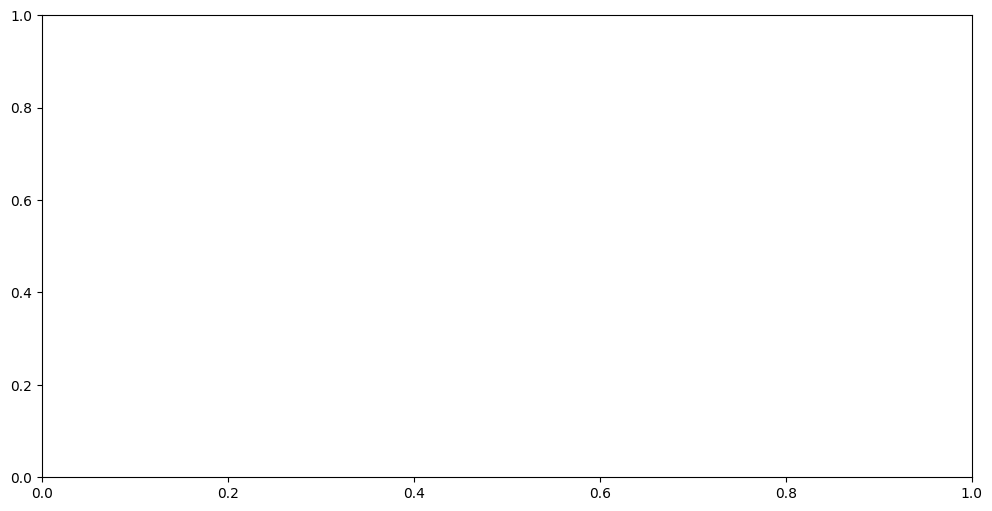

In [2]:
import matplotlib.pyplot as plt





fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True, sharey=True)



# Plot each array as a separate heatmap

im = ax.imshow(factors.reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-5, vmax=5)
ax.set_yticks([])  # Remove y-ticks
ax.set_ylabel(f"Array {i+1}")  # Label each row
fig.colorbar(im, ax=ax, orientation="vertical", label="Value")


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(betas[1][:10000].reshape(1, -1), betas[2][:10000].reshape(1, -1))


print(cos_sim)

[[0.86676249]]


In [8]:
face_betas = np.load("stacked_betas_faces.npy")
face_betas = face_betas.reshape(5, 3, 453622)


random_betas = np.load("stacked_betas_random.npy")
random_betas = random_betas.reshape(5, 3, 453622)


In [9]:
print(face_betas.shape)
print(random_betas.shape)


(5, 3, 453622)
(5, 3, 453622)


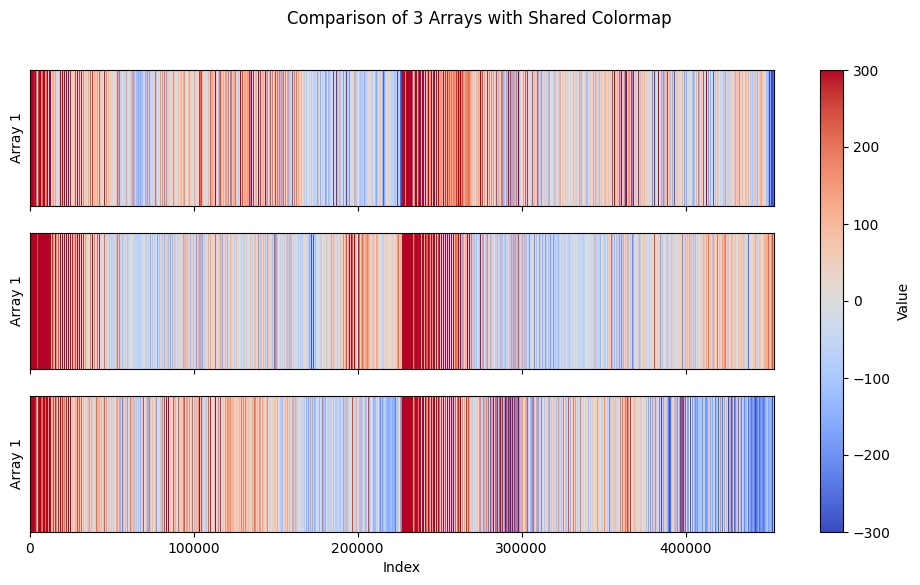

[[1.         0.21441307 0.27797198]
 [0.21441307 1.         0.252412  ]
 [0.27797198 0.252412   1.        ]]


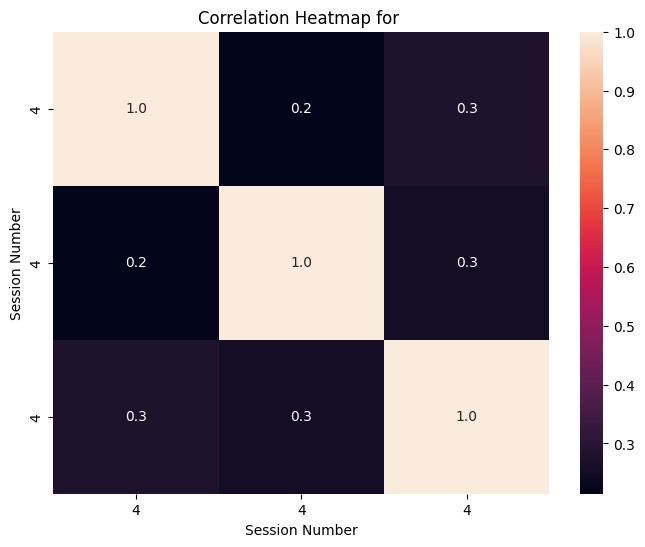

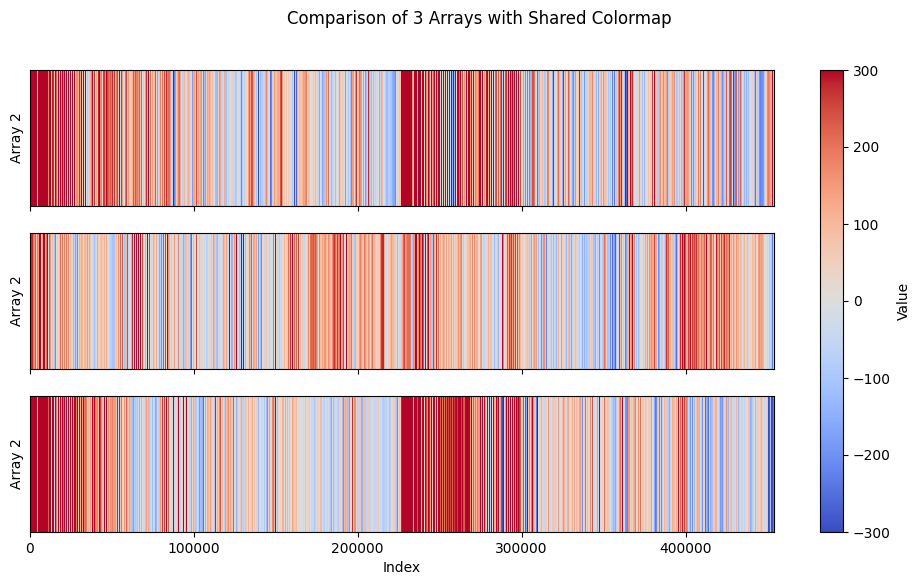

[[1.         0.07316707 0.2566337 ]
 [0.07316707 1.         0.20355578]
 [0.2566337  0.20355578 1.        ]]


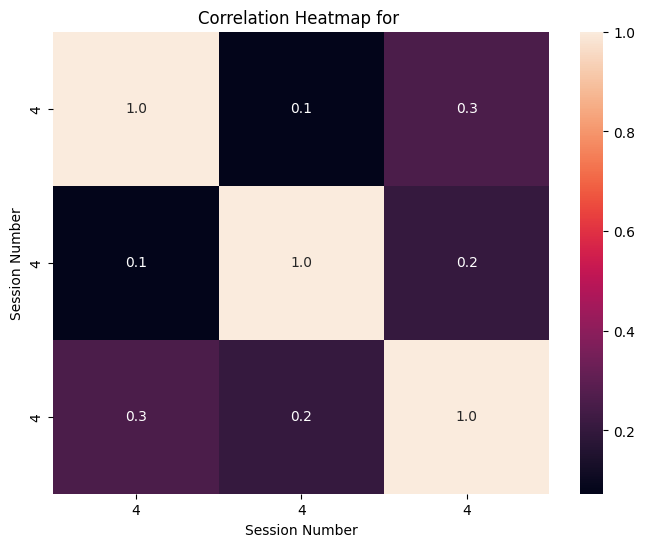

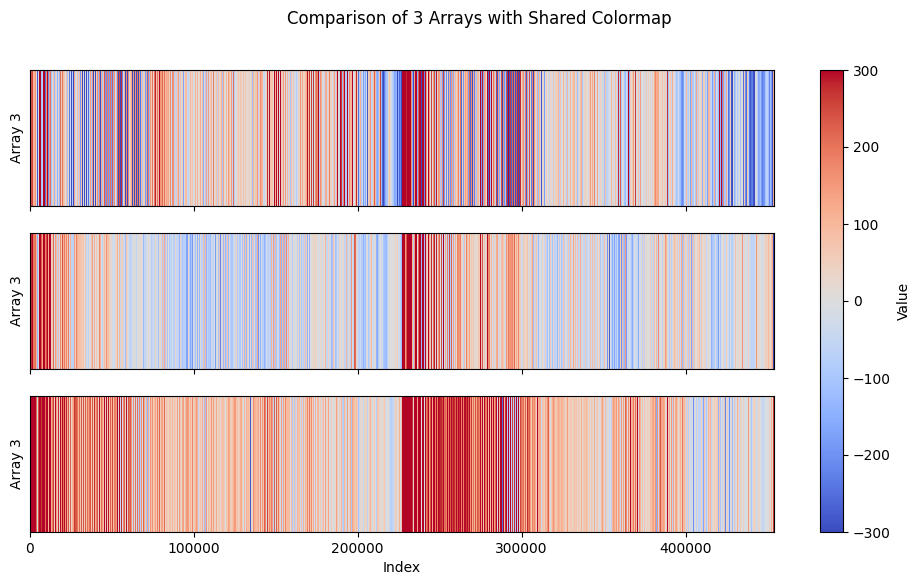

[[1.         0.22882705 0.26620501]
 [0.22882705 1.         0.24931249]
 [0.26620501 0.24931249 1.        ]]


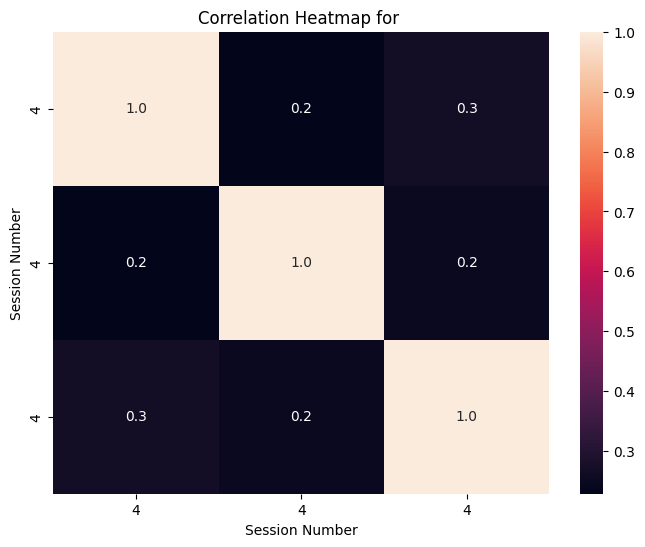

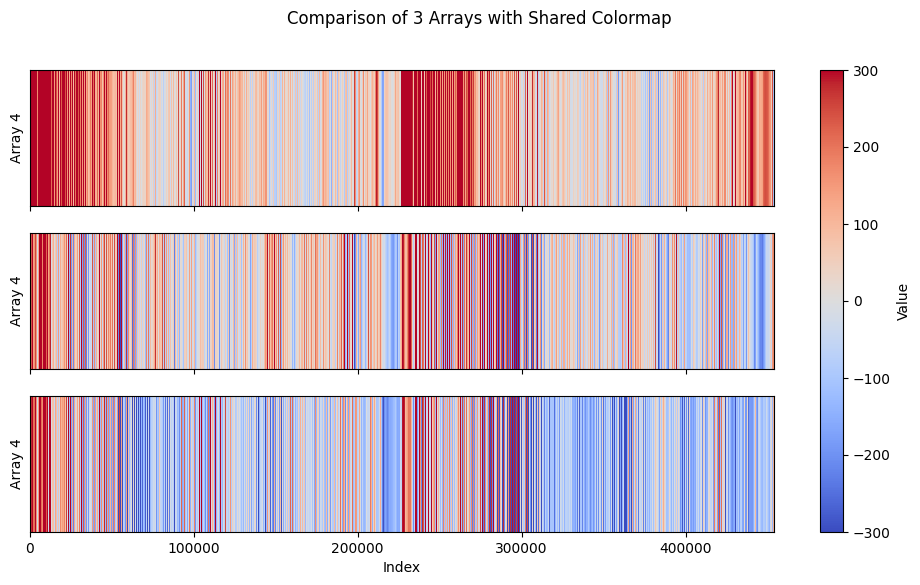

[[1.         0.18443067 0.27398248]
 [0.18443067 1.         0.35639843]
 [0.27398248 0.35639843 1.        ]]


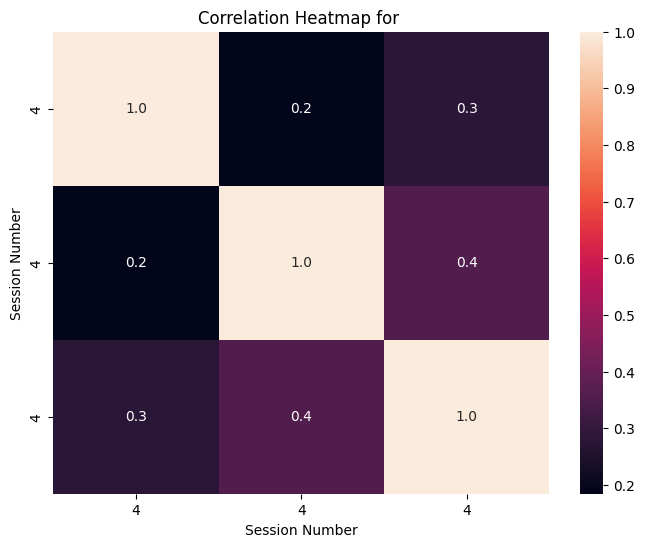

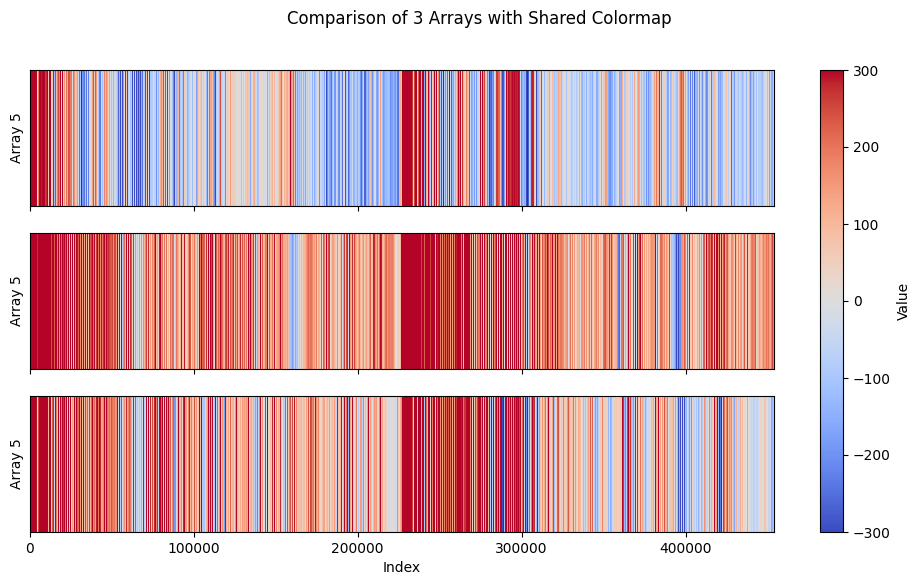

[[1.         0.26249932 0.40005461]
 [0.26249932 1.         0.45840434]
 [0.40005461 0.45840434 1.        ]]


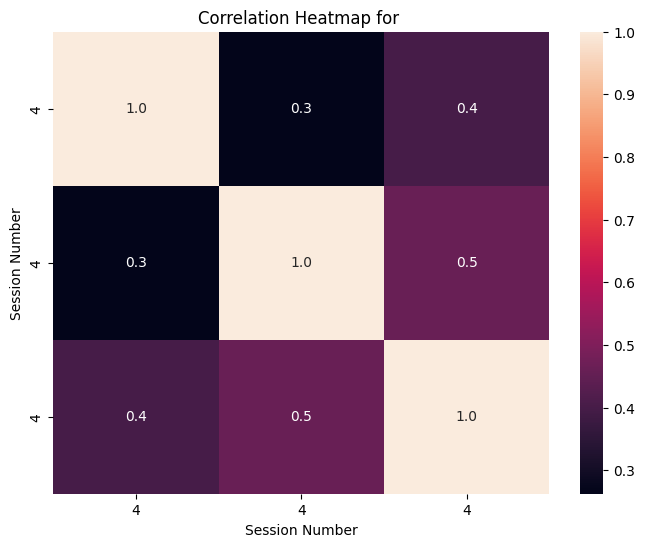

In [11]:

for i in range(len(face_betas)):
    betas = face_betas[i]
    fig, axes = plt.subplots(len(betas), 1, figsize=(12, 6), sharex=True, sharey=True)


    import scipy.stats
    import seaborn as sns

    # Plot each array as a separate heatmap
    for j, ax in enumerate(axes):
        im = ax.imshow(betas[j].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-300, vmax=300)
        ax.set_yticks([])  # Remove y-ticks
        ax.set_ylabel(f"Array {i+1}")  # Label each row

    # Colorbar (one for all plots)
    fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

    plt.xlabel("Index")
    plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
    plt.show()

    corrs = np.zeros((len(betas), len(betas)))
    for k in range(len(betas)):
        for j in range(len(betas)):
            corr = scipy.stats.pearsonr(betas[k], betas[j])
            corrs[k, j] = corr.statistic


    print(corrs)

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        corrs, 
        annot=True, 
        fmt=".1f", 
        cbar=True, 
        xticklabels=[4,4,4],  # Set x-axis labels
        yticklabels=[4,4,4]   # Set y-axis labels

    )
    plt.xlabel("Session Number")
    plt.ylabel("Session Number")
    plt.title(f"Correlation Heatmap for ")

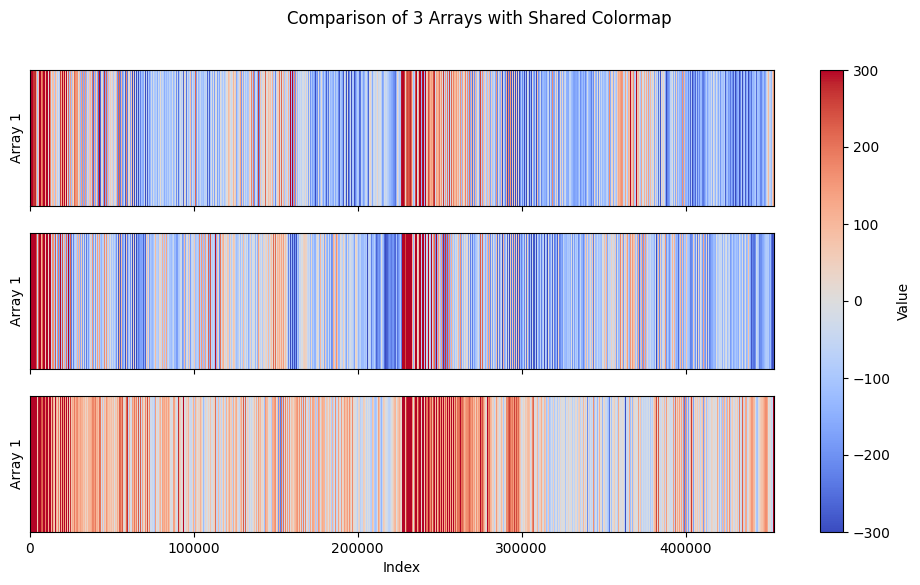

[[1.         0.16966097 0.13192625]
 [0.16966097 1.         0.12550422]
 [0.13192625 0.12550422 1.        ]]


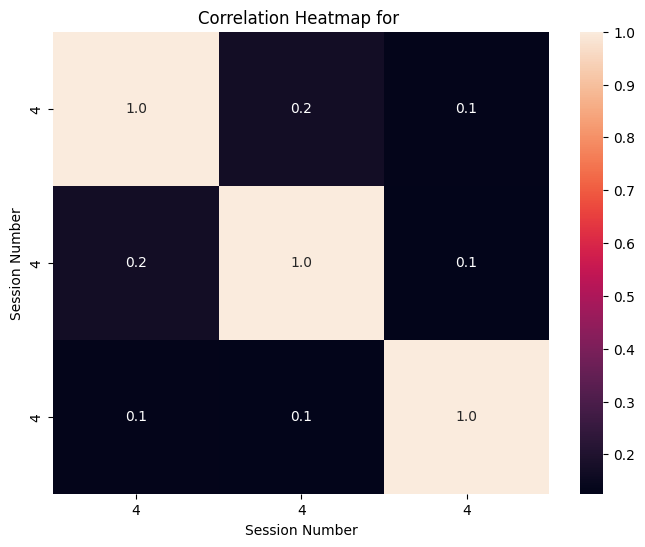

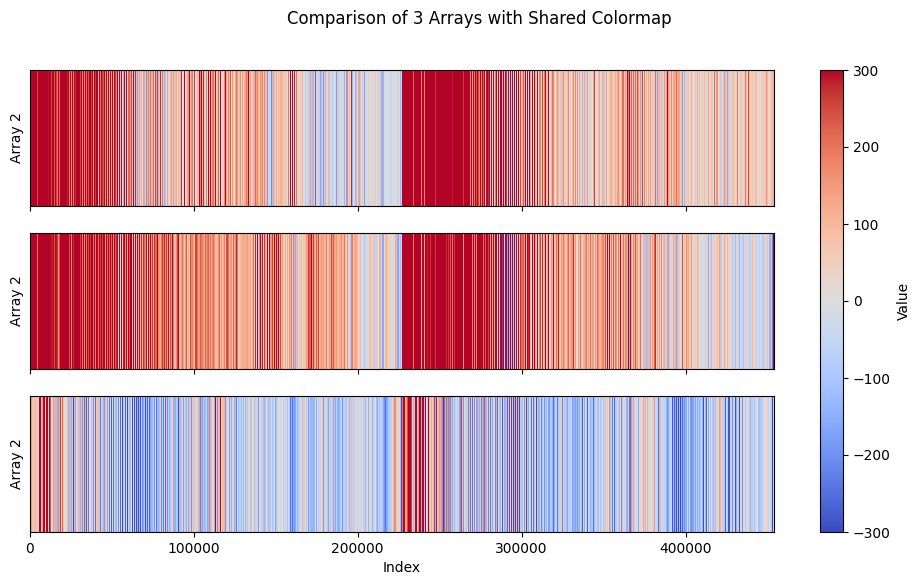

[[1.         0.33251545 0.15337278]
 [0.33251545 1.         0.18585293]
 [0.15337278 0.18585293 1.        ]]


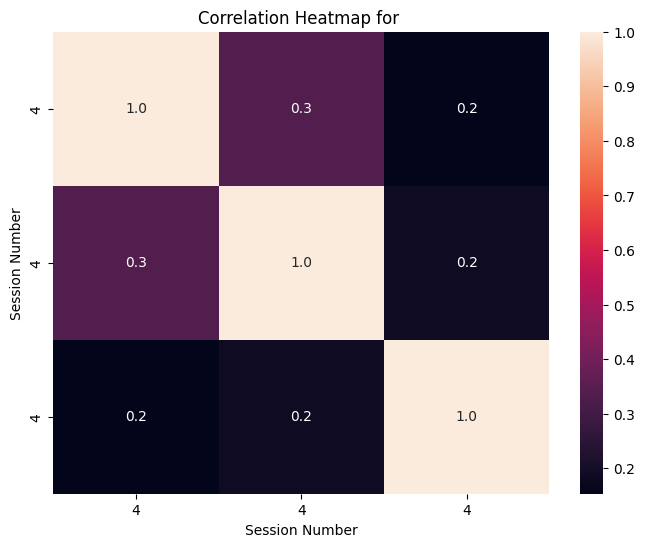

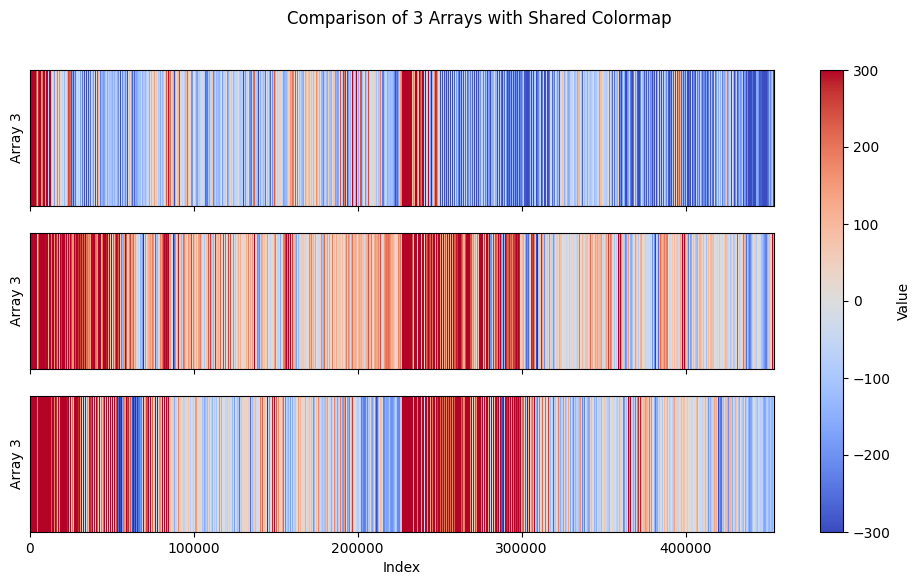

[[1.         0.21909227 0.23478905]
 [0.21909227 1.         0.38008384]
 [0.23478905 0.38008384 1.        ]]


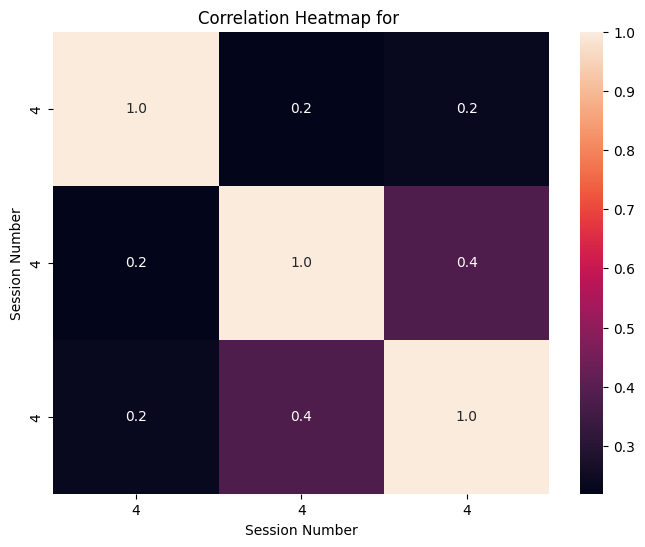

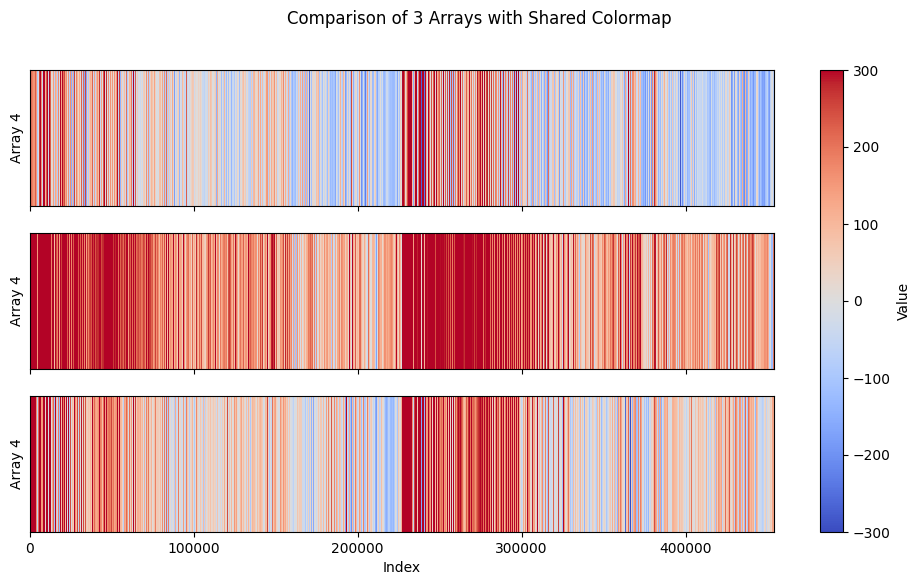

[[1.         0.30373509 0.31872721]
 [0.30373509 1.         0.40597339]
 [0.31872721 0.40597339 1.        ]]


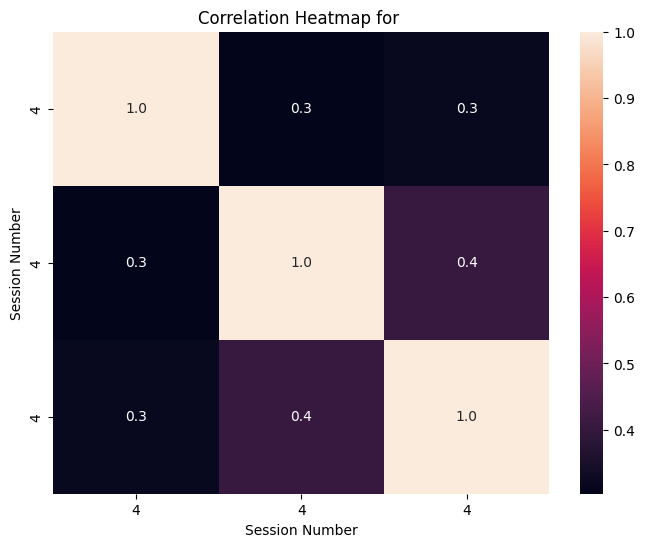

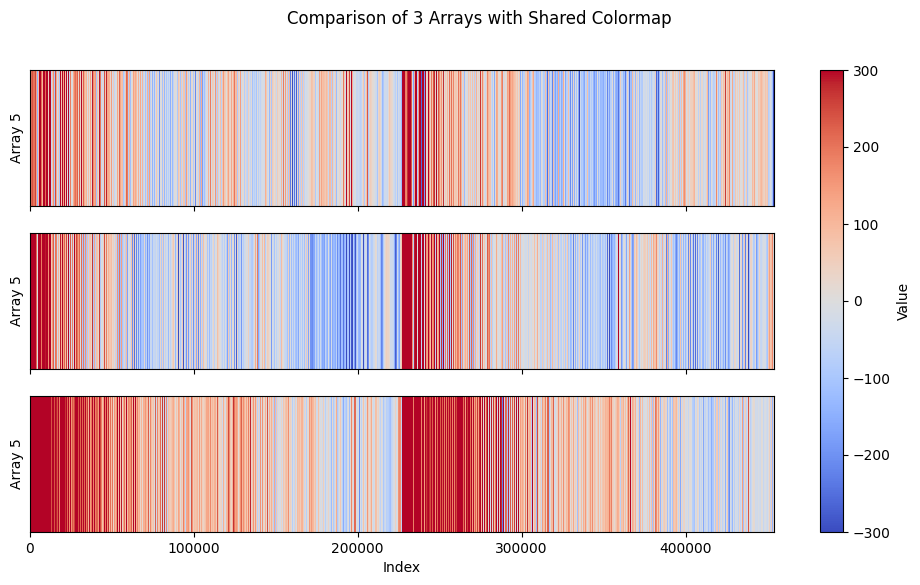

[[1.         0.18987962 0.26868236]
 [0.18987962 1.         0.2657722 ]
 [0.26868236 0.2657722  1.        ]]


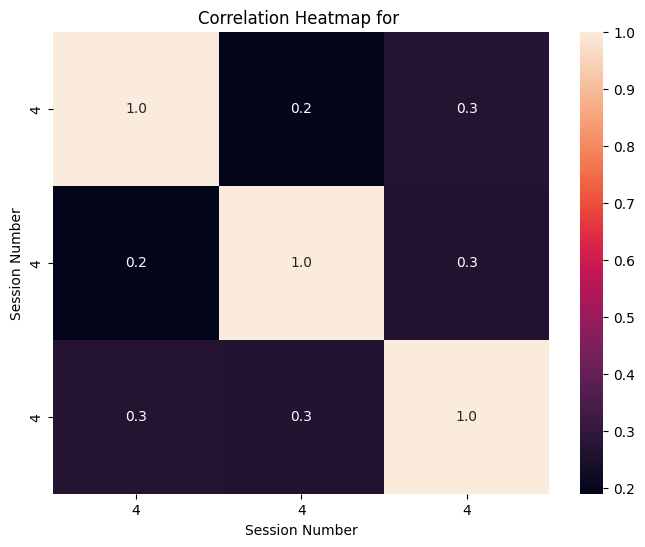

In [ ]:

for i in range(len(random_betas)):
    betas = random_betas[i]
    fig, axes = plt.subplots(len(betas), 1, figsize=(12, 6), sharex=True, sharey=True)


    import scipy.stats
    import seaborn as sns

    # Plot each array as a separate heatmap
    for j, ax in enumerate(axes):
        im = ax.imshow(betas[j].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-300, vmax=300)
        ax.set_yticks([])  # Remove y-ticks
        ax.set_ylabel(f"Array {i+1}")  # Label each row

    # Colorbar (one for all plots)
    fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

    plt.xlabel("Index")
    plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
    plt.show()

    corrs = np.zeros((len(betas), len(betas)))
    for k in range(len(betas)):
        for j in range(len(betas)):
            corr = scipy.stats.pearsonr(betas[k], betas[j])
            corrs[k, j] = corr.statistic


    print(corrs)

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        corrs, 
        annot=True, 
        fmt=".1f", 
        cbar=True, 
        xticklabels=[4,4,4],  # Set x-axis labels
        yticklabels=[4,4,4]   # Set y-axis labels

    )
    plt.xlabel("Session Number")
    plt.ylabel("Session Number")
    plt.title(f"Correlation Heatmap for ")

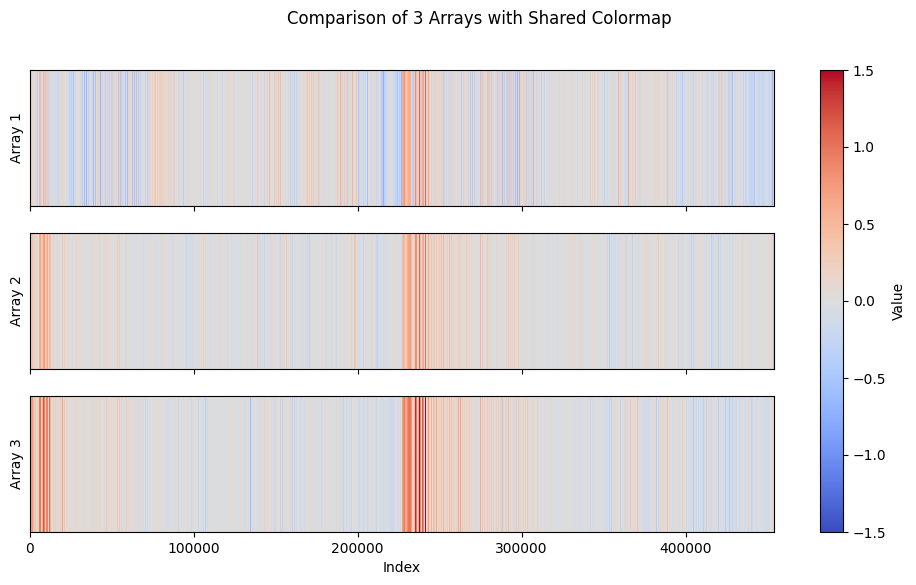

[[1.         0.17818394 0.20005099]
 [0.17818394 1.         0.24173791]
 [0.20005099 0.24173791 1.        ]]


Text(0.5, 1.0, 'Correlation Heatmap for ')

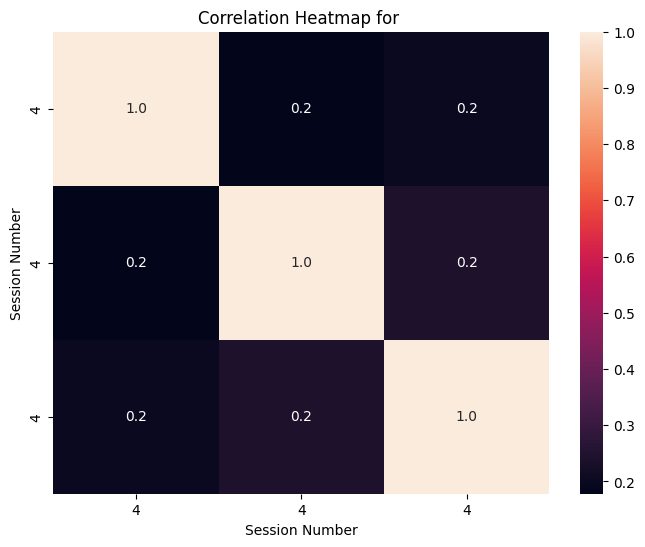

In [49]:
def standardize(arr):
    mean = np.mean(arr)
    std = np.std(arr)
    print(std)
    z_scores = (arr - mean) / std

    return z_scores

def standardize_arrays(multi_array):
    copy = multi_array.copy()
    stds = []
    for i in range(len(copy)):
        std = np.std(copy[i])
        stds.append(std)

    for i in range(len(copy)):
        mean = np.mean(copy[i])

        z_scores = (copy[i] - mean) / np.mean(np.array(stds))
        copy[i] = z_scores

    return copy
    



standardized_betas = standardize_arrays(betas)
fig, axes = plt.subplots(len(standardized_betas), 1, figsize=(12, 6), sharex=True, sharey=True)



# Plot each array as a separate heatmap
for i, ax in enumerate(axes):
    im = ax.imshow(standardized_betas[i].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-1.5, vmax=1.5)
    ax.set_yticks([])  # Remove y-ticks
    ax.set_ylabel(f"Array {i+1}")  # Label each row

# Colorbar (one for all plots)
fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

plt.xlabel("Index")
plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
plt.show()


corrs = np.zeros((len(standardized_betas), len(standardized_betas)))
for i in range(len(standardized_betas)):
    for j in range(len(standardized_betas)):
        corr = scipy.stats.pearsonr(standardized_betas[i], standardized_betas[j])
        corrs[i, j] = corr.statistic


print(corrs)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    corrs, 
    annot=True, 
    fmt=".1f", 
    cbar=True, 
    xticklabels=[4,4,4],  # Set x-axis labels
    yticklabels=[4,4,4]   # Set y-axis labels

)
plt.xlabel("Session Number")
plt.ylabel("Session Number")
plt.title(f"Correlation Heatmap for ")

In [58]:
import scipy.stats as stats

def rank_transform(data):
    return stats.rankdata(data)

ranked_sample0 = rank_transform(betas[0])
ranked_sample1 = rank_transform(betas[1])

print(ranked_sample0)


spearman_corr, _ = stats.spearmanr(ranked_sample0, ranked_sample1)

print(spearman_corr)

[382879.  373241.5 376840.5 ... 295608.  293756.5 228213.5]
0.23187160697907325


In [14]:
import numpy as np
import scipy.stats as stats

def sliding_window_correlation(arr1, arr2, window_size):
    assert len(arr1) == len(arr2), "Arrays müssen die gleiche Länge haben!"
    
    n = len(arr1)
    result = np.full(n, np.nan)  # Ergebnis-Array mit NaNs initialisieren
    
    
    for i in range(0, n, window_size):  # Über das Array iterieren
        window1 = arr1[i : i + window_size]  # Subarray aus Sample 1
        window2 = arr2[i : i + window_size]  # Subarray aus Sample 2
        
        corr, _ = stats.pearsonr(window1, window2)  # Spearman-Korrelation berechnen
        
        result[i: i+window_size] = corr
        # result[i] = corr  # Ergebnis speichern
    
    return result



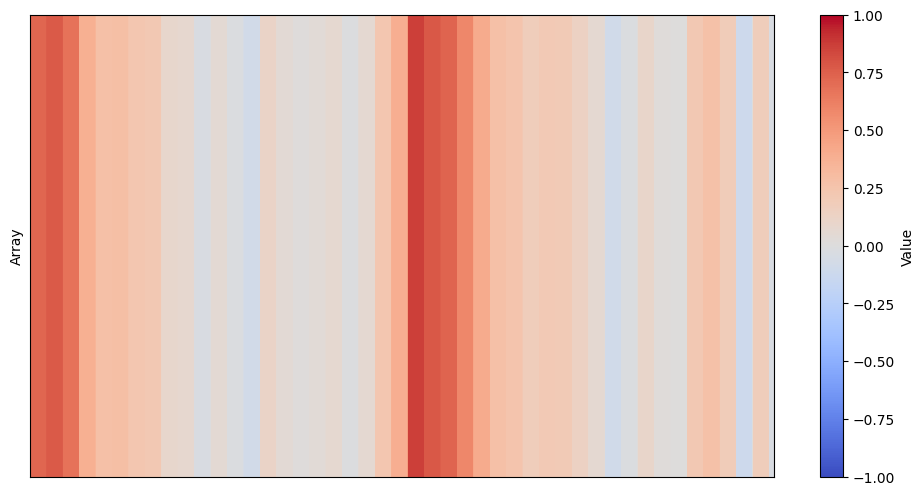

In [65]:
binned_correlation = sliding_window_correlation(betas[0], betas[1] , 10000)


fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True, sharey=True)



# Plot each array as a separate heatmap
im = ax.imshow(binned_correlation.reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks([])
ax.set_yticks([])  # Remove y-ticks
ax.set_ylabel(f"Array")  # Label each row

# Colorbar (one for all plots)
fig.colorbar(im, ax=ax, orientation="vertical", label="Value")

# plt.xlabel("Index")
# plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
# plt.show()





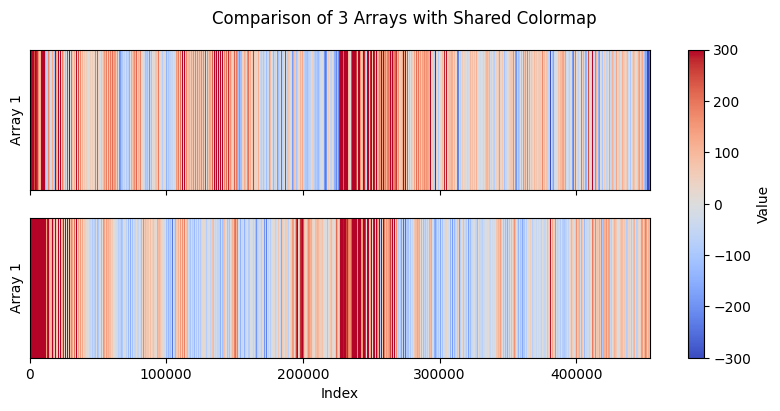

[[1.         0.21441307]
 [0.21441307 1.        ]]
np.mean(binned_correlation)=np.float64(0.19353690681448524)


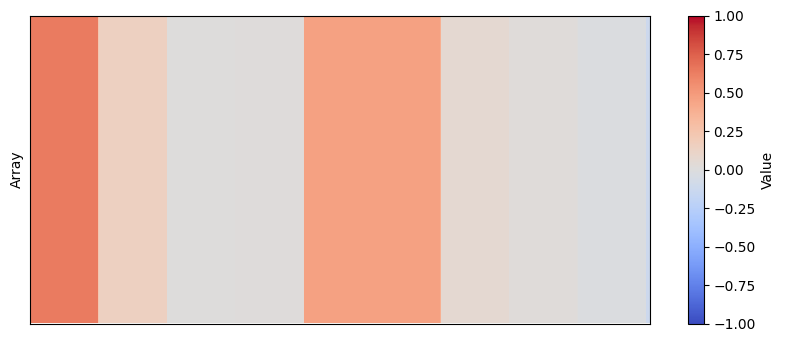

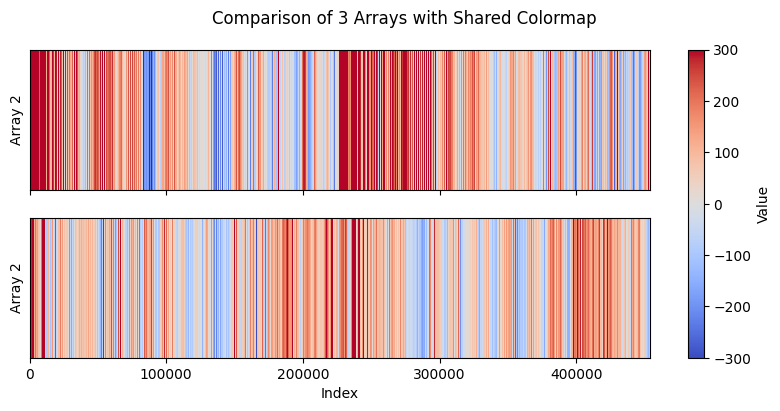

[[1.         0.07316707]
 [0.07316707 1.        ]]
np.mean(binned_correlation)=np.float64(0.09558101962303717)


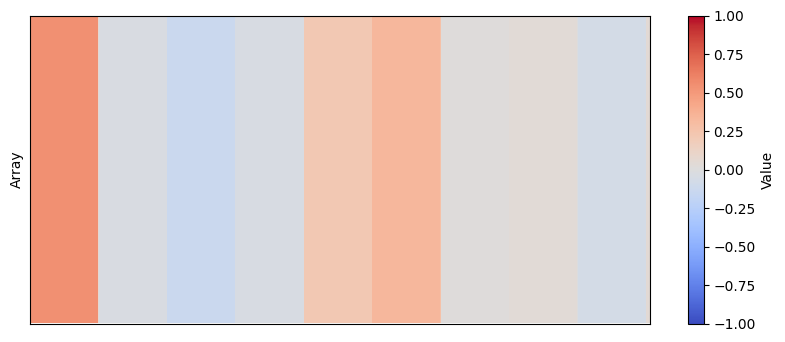

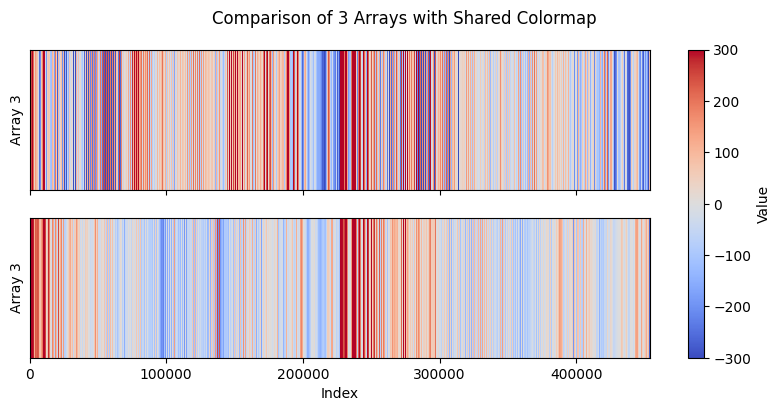

[[1.         0.22882705]
 [0.22882705 1.        ]]
np.mean(binned_correlation)=np.float64(0.2298860612624492)


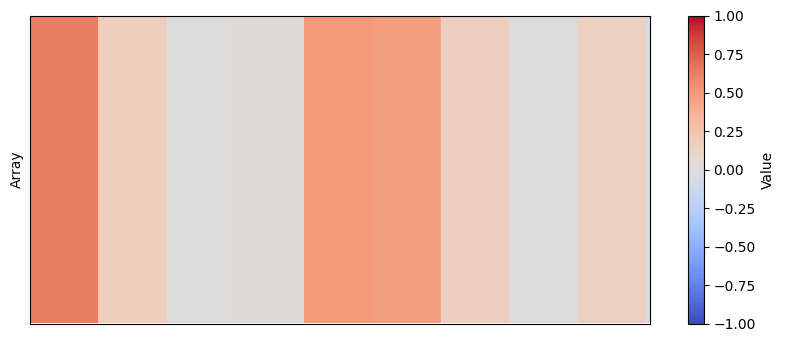

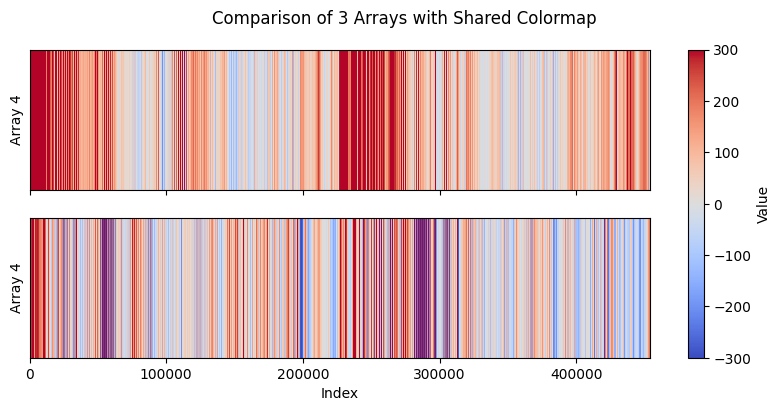

[[1.         0.18443067]
 [0.18443067 1.        ]]
np.mean(binned_correlation)=np.float64(0.1754456958835064)


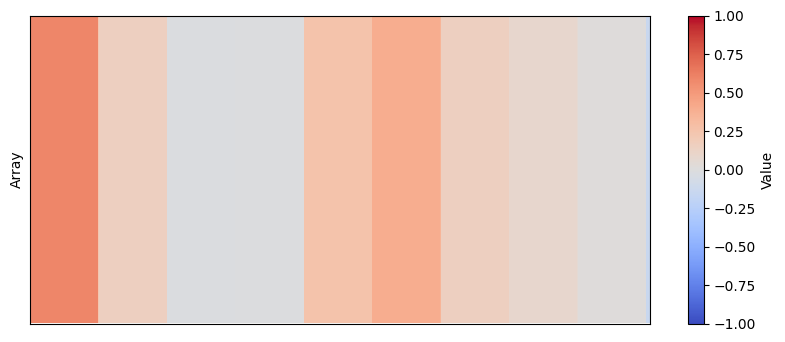

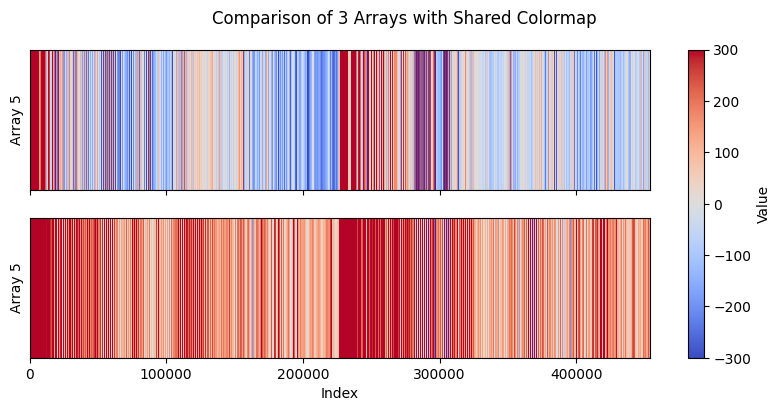

[[1.         0.26249932]
 [0.26249932 1.        ]]
np.mean(binned_correlation)=np.float64(0.2556693875641)


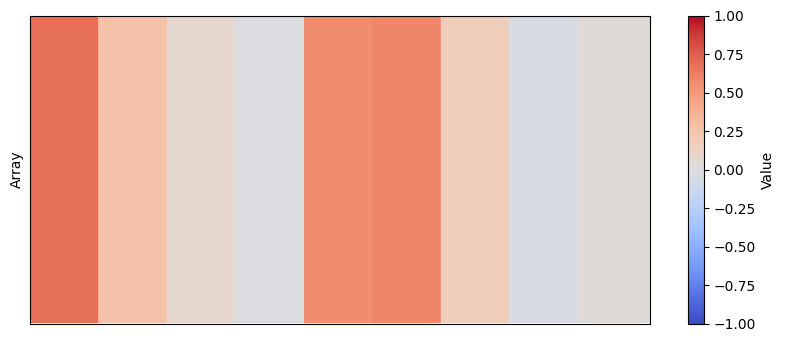

In [24]:

for i in range(len(face_betas)):
    betas = face_betas[i]
    fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True, sharey=True)


    import scipy.stats
    import seaborn as sns

    # Plot each array as a separate heatmap
    for j, ax in enumerate(axes):
        im = ax.imshow(betas[j].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-300, vmax=300)
        ax.set_yticks([])  # Remove y-ticks
        ax.set_ylabel(f"Array {i+1}")  # Label each row

    # Colorbar (one for all plots)
    fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

    plt.xlabel("Index")
    plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
    plt.show()

    corrs = np.zeros((len(axes), len(axes)))
    for k in range(len(axes)):
        for j in range(len(axes)):
            corr = scipy.stats.pearsonr(betas[k], betas[j])
            corrs[k, j] = corr.statistic


    print(corrs)

    # plt.figure(figsize=(8, 6))
    # ax = sns.heatmap(
    #     corrs, 
    #     annot=True, 
    #     fmt=".1f", 
    #     cbar=True, 
    #     xticklabels=[4,4],  # Set x-axis labels
    #     yticklabels=[4,4]   # Set y-axis labels

    # )
    # plt.xlabel("Session Number")
    # plt.ylabel("Session Number")
    # plt.title(f"Correlation Heatmap for ")

    # plt.show()


    binned_correlation = sliding_window_correlation(betas[0], betas[1] , 50000)
    print(f"{np.mean(binned_correlation)=}")


    fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True, sharey=True)



    # Plot each array as a separate heatmap
    im = ax.imshow(binned_correlation.reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])  # Remove y-ticks
    ax.set_ylabel(f"Array")  # Label each row

    # Colorbar (one for all plots)
    fig.colorbar(im, ax=ax, orientation="vertical", label="Value")

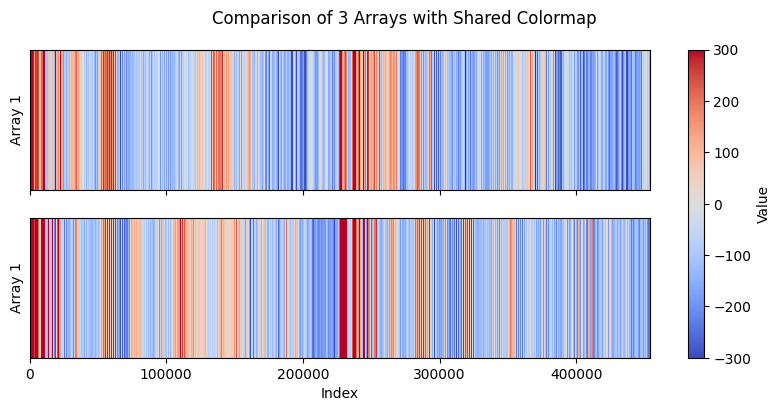

[[1.         0.16966097]
 [0.16966097 1.        ]]
np.mean(binned_correlation)=np.float64(0.18134161654046815)


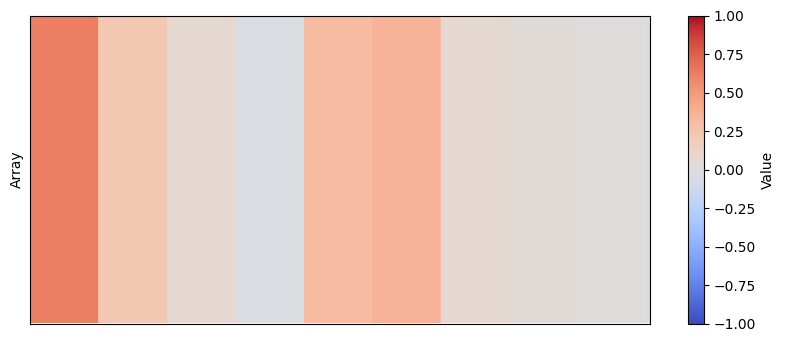

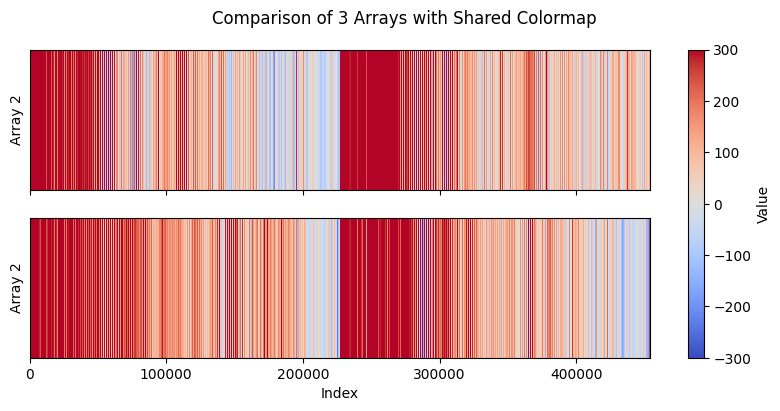

[[1.         0.33251545]
 [0.33251545 1.        ]]
np.mean(binned_correlation)=np.float64(0.27904645223430014)


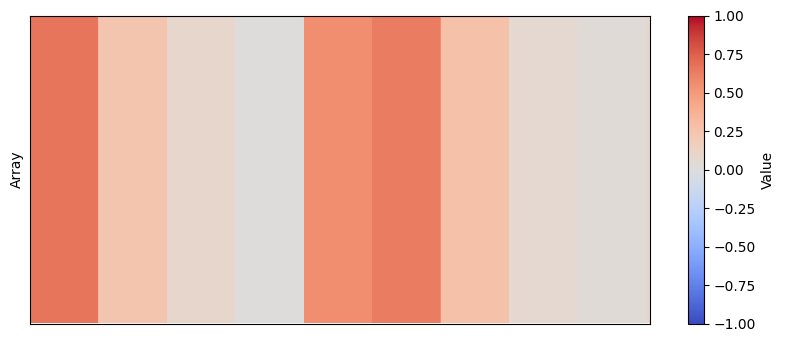

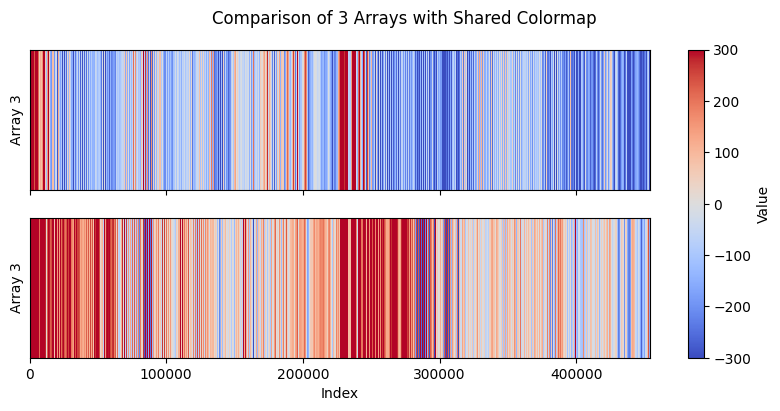

[[1.         0.21909227]
 [0.21909227 1.        ]]
np.mean(binned_correlation)=np.float64(0.19767281253987165)


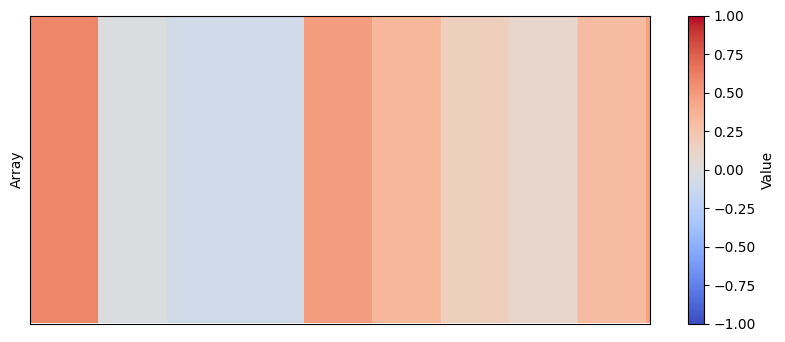

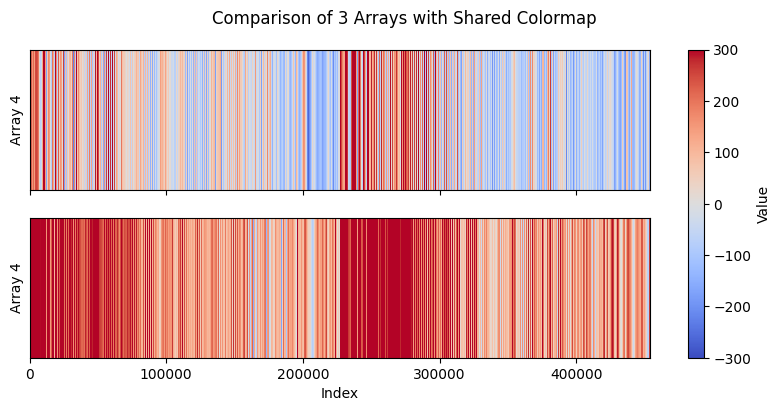

[[1.         0.30373509]
 [0.30373509 1.        ]]
np.mean(binned_correlation)=np.float64(0.28193483649150725)


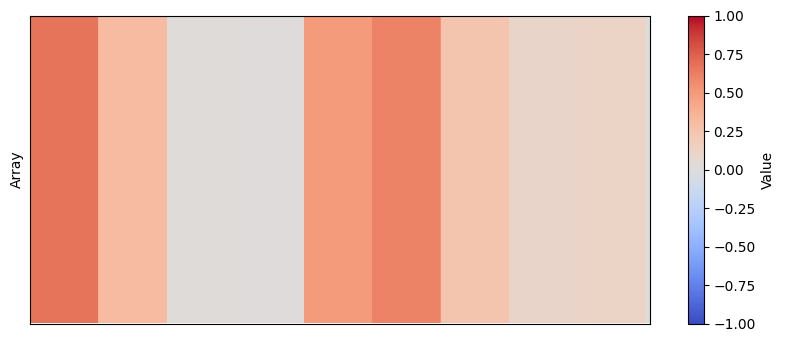

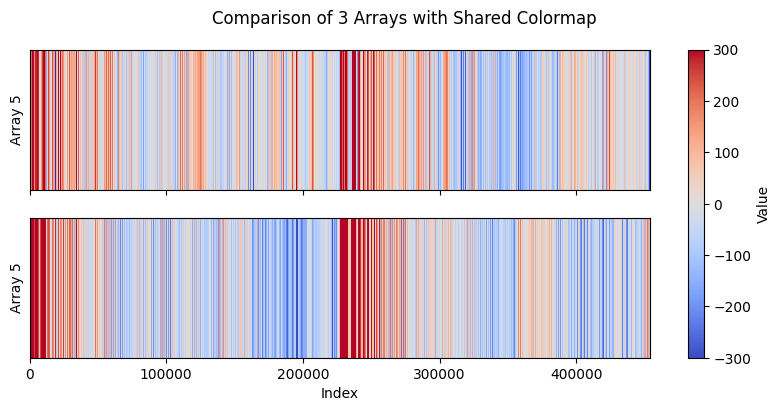

[[1.         0.18987962]
 [0.18987962 1.        ]]
np.mean(binned_correlation)=np.float64(0.1592559594189651)


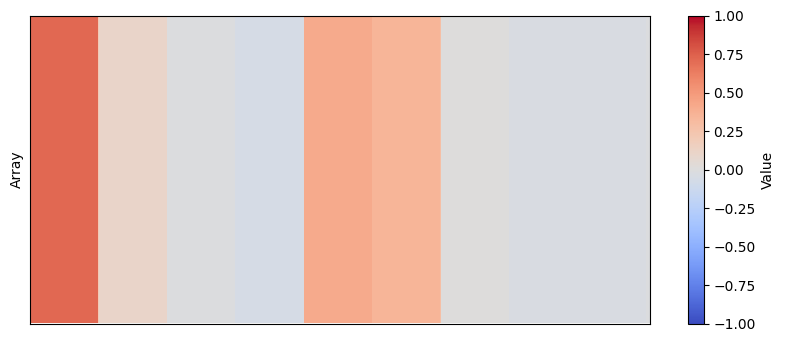

In [25]:

for i in range(len(random_betas)):
    betas = random_betas[i]
    fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True, sharey=True)


    import scipy.stats
    import seaborn as sns

    # Plot each array as a separate heatmap
    for j, ax in enumerate(axes):
        im = ax.imshow(betas[j].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-300, vmax=300)
        ax.set_yticks([])  # Remove y-ticks
        ax.set_ylabel(f"Array {i+1}")  # Label each row

    # Colorbar (one for all plots)
    fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

    plt.xlabel("Index")
    plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
    plt.show()

    corrs = np.zeros((len(axes), len(axes)))
    for k in range(len(axes)):
        for j in range(len(axes)):
            corr = scipy.stats.pearsonr(betas[k], betas[j])
            corrs[k, j] = corr.statistic


    print(corrs)

    # plt.figure(figsize=(8, 6))
    # ax = sns.heatmap(
    #     corrs, 
    #     annot=True, 
    #     fmt=".1f", 
    #     cbar=True, 
    #     xticklabels=[4,4],  # Set x-axis labels
    #     yticklabels=[4,4]   # Set y-axis labels

    # )
    # plt.xlabel("Session Number")
    # plt.ylabel("Session Number")
    # plt.title(f"Correlation Heatmap for ")

    # plt.show()


    binned_correlation = sliding_window_correlation(betas[0], betas[1] , 50000)
    print(f"{np.mean(binned_correlation)=}")


    fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True, sharey=True)



    # Plot each array as a separate heatmap
    im = ax.imshow(binned_correlation.reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])  # Remove y-ticks
    ax.set_ylabel(f"Array")  # Label each row

    # Colorbar (one for all plots)
    fig.colorbar(im, ax=ax, orientation="vertical", label="Value")

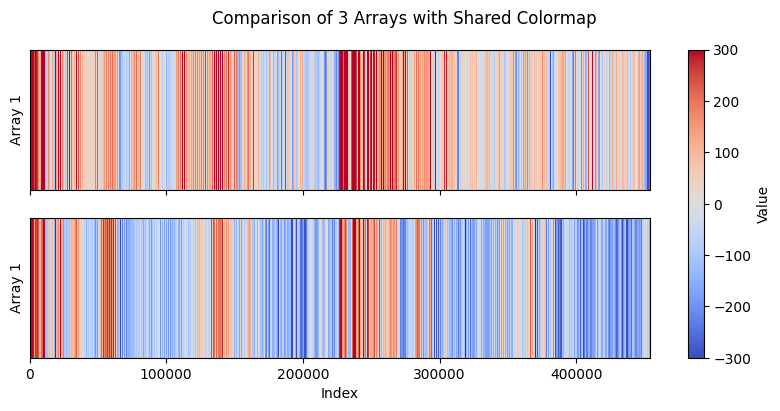

[[1.        0.1957352]
 [0.1957352 1.       ]]
np.mean(binned_correlation)=np.float64(0.2102666728521308)


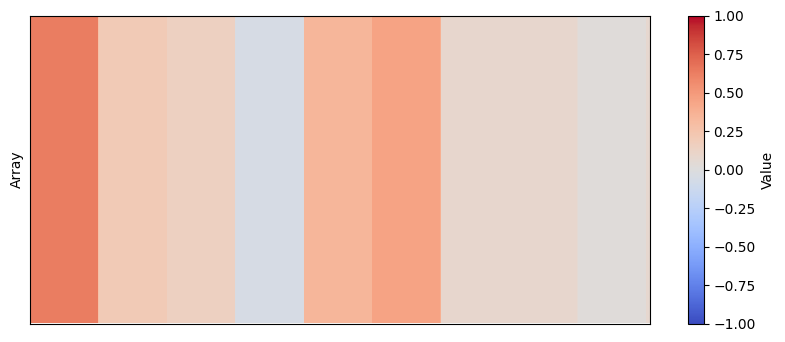

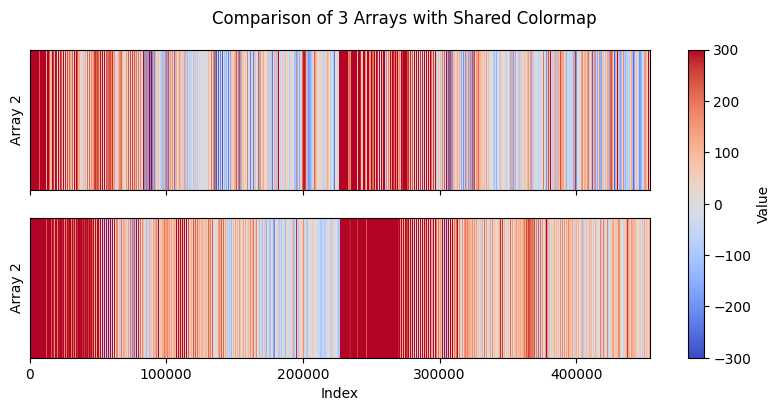

[[1.         0.23276648]
 [0.23276648 1.        ]]
np.mean(binned_correlation)=np.float64(0.1891977048420276)


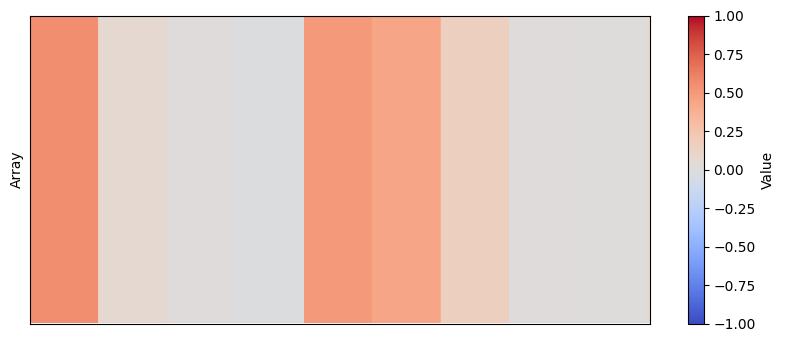

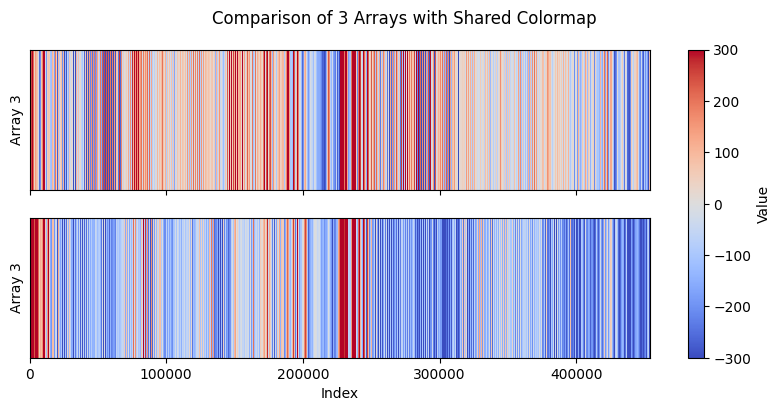

[[1.         0.25661947]
 [0.25661947 1.        ]]
np.mean(binned_correlation)=np.float64(0.2399307890078812)


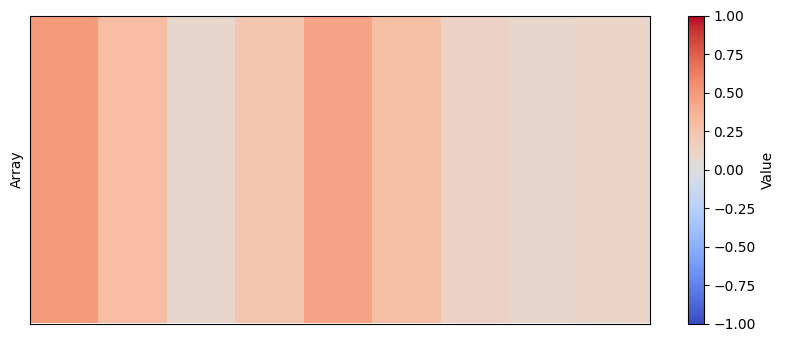

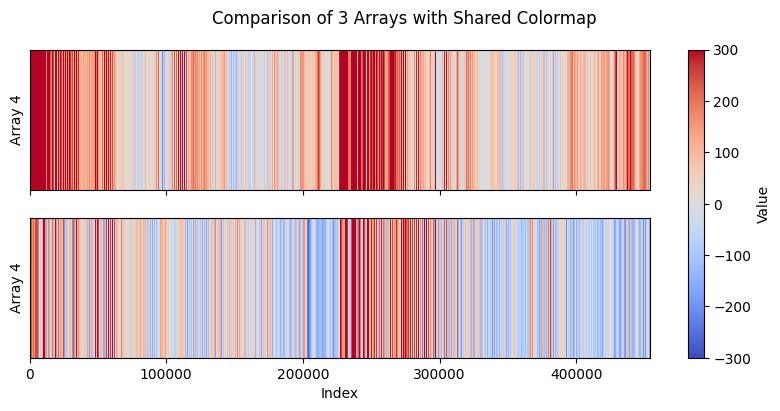

[[1.         0.22733425]
 [0.22733425 1.        ]]
np.mean(binned_correlation)=np.float64(0.19306580889217584)


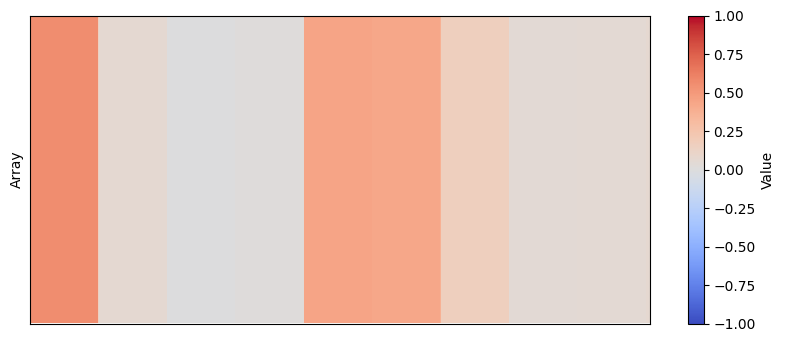

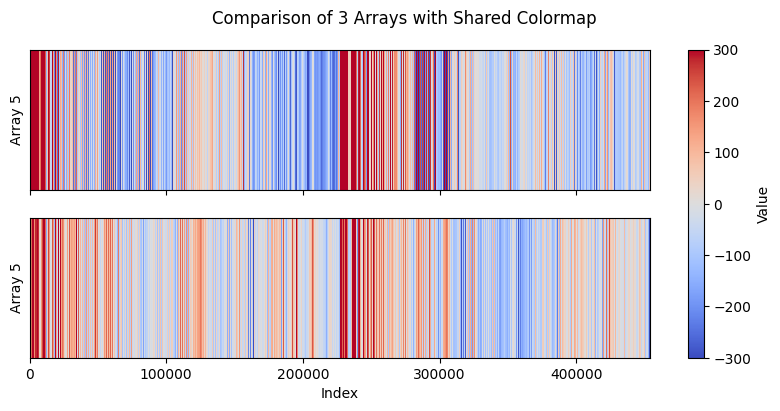

[[1.         0.18874396]
 [0.18874396 1.        ]]
np.mean(binned_correlation)=np.float64(0.17166620610015737)


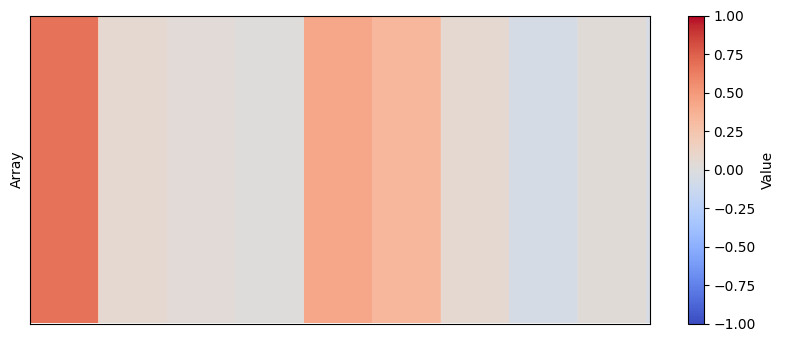

In [26]:
mixed_betas = face_betas.copy()

for i in range(len(random_betas)):
    for j in range(2):
        if j == 0:
            mixed_betas[i][j] = face_betas[i][0]
        else:
            mixed_betas[i][j] = random_betas[i][0]



for i in range(len(mixed_betas)):
    betas = mixed_betas[i]
    fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True, sharey=True)


    import scipy.stats
    import seaborn as sns

    # Plot each array as a separate heatmap
    for j, ax in enumerate(axes):
        im = ax.imshow(betas[j].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-300, vmax=300)
        ax.set_yticks([])  # Remove y-ticks
        ax.set_ylabel(f"Array {i+1}")  # Label each row

    # Colorbar (one for all plots)
    fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

    plt.xlabel("Index")
    plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
    plt.show()

    corrs = np.zeros((len(axes), len(axes)))
    for k in range(len(axes)):
        for j in range(len(axes)):
            corr = scipy.stats.pearsonr(betas[k], betas[j])
            corrs[k, j] = corr.statistic


    print(corrs)

    # plt.figure(figsize=(8, 6))
    # ax = sns.heatmap(
    #     corrs, 
    #     annot=True, 
    #     fmt=".1f", 
    #     cbar=True, 
    #     xticklabels=[4,4],  # Set x-axis labels
    #     yticklabels=[4,4]   # Set y-axis labels

    # )
    # plt.xlabel("Session Number")
    # plt.ylabel("Session Number")
    # plt.title(f"Correlation Heatmap for ")

    # plt.show()


    binned_correlation = sliding_window_correlation(betas[0], betas[1] , 50000)
    print(f"{np.mean(binned_correlation)=}")


    fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True, sharey=True)



    # Plot each array as a separate heatmap
    im = ax.imshow(binned_correlation.reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])  # Remove y-ticks
    ax.set_ylabel(f"Array")  # Label each row

    # Colorbar (one for all plots)
    fig.colorbar(im, ax=ax, orientation="vertical", label="Value")

In [29]:
import sys


import os

sys.path.append(os.path.abspath(".."))
from utils.config import Configuration, load_config




config = load_config("../config.yaml")

mask_dir = os.path.join(config.stans_thesis_repo_data, config.mask_data_dir)

In [ ]:
hemis = ["lh", "rh"]
import nibabel as nib
sub = "subj01"

hemisphere_shapes = []

loop = [
    [(face_betas[0][0], face_betas[0][1]),
    "correlation.mgz"],
    [(random_betas[0][0], face_betas[0][2]),
    "correlation_different.mgz"]
    ]




for l in loop:
    binned_correlation = sliding_window_correlation(betas[0], betas[1] , 10000)
    for hemi_i, hemi in enumerate(hemis):

        maskdata_long_file = os.path.join(
            mask_dir, sub, f"{hemi}.{sub}.testrois.mgz"
        )
        maskdata_long = nib.load(maskdata_long_file).get_fdata().squeeze()

        hemisphere_shapes.append(maskdata_long.shape[0])

        data_out = np.zeros(maskdata_long.shape)

        data_out_file = os.path.join(
                    config.freesurfer_dir,
                    sub,
                    "label",
                    f"{hemi}.{l[1]}",
                )
        
        if hemi_i == 0:
            data_out = binned_correlation[:maskdata_long.shape[0]]
        else:
            data_out = binned_correlation[maskdata_long.shape[0]:]

        img = nib.Nifti1Image(np.expand_dims(data_out, axis=(1, 2)), np.eye(4))
        nib.loadsave.save(img, data_out_file)

        
